# Example of beam basic beam acceleration

In [1]:
import logging
import os
import numpy as np
from matplotlib import pyplot as plt

from blond import (
    Beam,
    BeamObservationOncePerTurn,
    BiGaussian,
    DriftSimple,
    MagneticCyclePerTurn,
    RFStationPhaseObservation,
    Ring,
    Simulation,
    SingleHarmonicRFStation,
    momentum_compaction_factor,
    proton,
    backend,
)
from blond.experimental import (
    SemiEmpiricMatcher,
)

# When testing, some variables migh be changed for performace..
testing = os.environ.get("PYTEST_CURRENT_TEST", None) is not None

Using environment variable BLOND_BACKEND_MODE = python
Changing backend to `Numpy64Bit`


/home/slauber/PycharmProjects/deleteme/blonder/.venv_py313/lib/python3.13/site-packages/blond/experimental/__init__.py:34: ExperimentalFeaturesWarning: 
Importing experimental features. These are under development and are
liable to change or be removed without warning.

  warnings.warn(_msg, ExperimentalFeaturesWarning, stacklevel=1)


In [2]:
ring = Ring(26658.883)

rf_station = SingleHarmonicRFStation()
rf_station.harmonic = 35640
rf_station.voltage = 6e6
rf_station.phi_rf_design = 0

N_TURNS = int(1e3)

energy_cycle = MagneticCyclePerTurn(
    value_init=450e9,
    values_after_turn=np.linspace(450e9, 450e9, N_TURNS),
    reference_particle=proton,
)

drift1 = DriftSimple(
    orbit_length=26658.883,
)
drift1.momentum_compaction_factor = momentum_compaction_factor(
    transition_gamma=55.759505
)
beam1 = Beam(
    intensity=1e9,
    particle_type=proton,
)

sim = Simulation.from_locals(locals())
sim.print_one_turn_execution_order()

------------------------------------------------------------------------------
Execution order
---------------
element.name                             type                 section_index filtered_dict
Unnamed-SingleHarmonicRFStation-001      SingleHarmonicRFStation 0             {'schedules': {}, 'schedule_active': False, 'each_turn_i': 1, 'active': True, 'observables': {}, 'cavity_feedback_list': [None], 'omega_rf_design': None, 'delta_omega_rf': 0.0, 'phi_rf_design': 0, 'delta_phi_rf': 0.0, 'voltage': 6000000.0, 'harmonic': 35640}
Unnamed-DriftSimple-001                  DriftSimple          0             {'schedules': {}, 'schedule_active': False, 'each_turn_i': 1, 'active': True, 'observables': {}, 'orbit_length': 26658.883, 'momentum_compaction_factor': 0.0003216341694019874}
------------------------------------------------------------------------------



/home/slauber/PycharmProjects/deleteme/blonder/.venv_py313/lib/python3.13/site-packages/blond/core/simulation/simulation.py:569: PerformanceWarning: There are more than 1000 particles in your beam. Consider using another backend via
 >>> from blond import backend
 >>> backend.set_specials(mode=...)
  deepcopy(self).run_simulation(



Beam 0 has 10.23k macroparticles 245.52kB
n_turns=1
n_elements=2


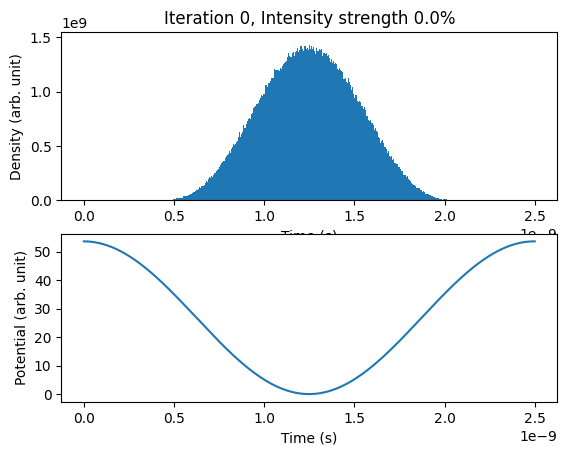

In [3]:
sim.prepare_beam(
    beam=beam1,
    preparation_routine=SemiEmpiricMatcher(
        time_limit=(0, 2.5e-9),
        n_macroparticles=1e3 if testing else 1e6,
        seed=0,
        maxiter_intensity_effects=0,
        hamilton_to_density_kwargs=dict(
            density_modifier=2.0,  # Controls density profile sharpness
            hamilton_max=40.0,  # Hamiltonian cutoff [eV]
        ),
        animate=True,
    ),
)

Text(0.5, 0, 'Energy Offset [eV]')

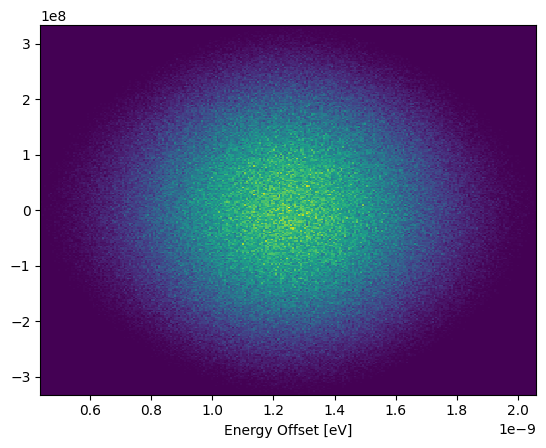

In [4]:
beam1.plot_hist2d()
plt.xlabel("Time [s]")
plt.xlabel("Energy Offset [eV]")

In [5]:
phase_observation = RFStationPhaseObservation(
    each_turn_i=1,
    rf_station=rf_station,
)
bunch_observation = BeamObservationOncePerTurn(each_turn_i=int(1e3 - 1))

beam1._dt.array_local += 0.25e-9

if not testing:
    backend.set_specials("numba")

sim.run_simulation(
    beams=(beam1,),
    n_turns=N_TURNS,
    observe=(phase_observation, bunch_observation),
)

Set special to `numba`

Beam 0 has 1.00M macroparticles 24.00MB
n_turns=1000
n_elements=2


BLonD3 mainloop: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 374.30it/s, 2.580000ns per particle]


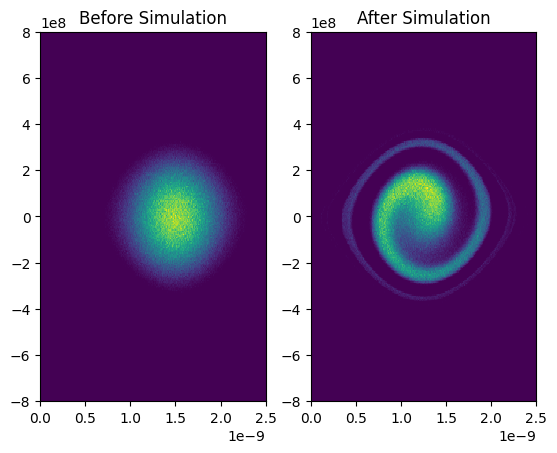

In [6]:
plt.figure()
ax = plt.subplot(1, 2, 1)
plt.title("Before Simulation")
plt.hist2d(
    bunch_observation.dts[0, :],
    bunch_observation.dEs[0, :],
    bins=256,
    range=[[0, 2.5e-9], [-8e8, 8e8]],
)
plt.subplot(1, 2, 2, sharex=ax)
plt.title("After Simulation")
plt.hist2d(
    bunch_observation.dts[-1, :],
    bunch_observation.dEs[-1, :],
    bins=256,
    range=[[0, 2.5e-9], [-8e8, 8e8]],
)

plt.show()